<a href="https://colab.research.google.com/github/soda1102/AI_26/blob/main/07_02_%EC%8B%AC%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D(%EB%94%A5%EB%9F%AC%EB%8B%9D).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# 인공신경망에 층을 추가하여 데이터셋을 분류하면 딥러닝 → 심층신경망

# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만든다.
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras

# 케라스 API에서 패션 MNIST 데이터셋을 불러온다.
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# 훈련세트와 테스트셋을 만든다.

In [18]:
from sklearn.model_selection import train_test_split

# 이미지의 픽셀 값이 0 ~ 155 범위에서 0 ~ 1사이로 변환
train_scaled = train_input / 255.0

# 28 * 28 크기의 2차원 배열을 만들어 784 크기의 1차원 배열로 펼친다.
train_scaled = train_scaled.reshape(-1, 28 * 28)

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42)

# 20%의 훈련세트와 검증세트로 분할

In [19]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [20]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [21]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [57]:
# 인공신경망 모델에 2개의 레이어를 추가해보겠다.

# 입력층 → 은닉층 → 출력층
# 입력층 : 데이터가 처음 들어오는 곳, 별도 계산 없이 데이터를 신경망에 전달하는 통로 역할
# 은닉층 : 숨겨져있는 모든 층, 데이터의 복잡한 패턴 학습, 계산하는 모델의 핵심부위. 층이 많아질 수록 더 똑똑해진다.
# 출력층 : 마지막에 위치, 최종 결과물을 내놓는 곳. 이진분류일때 노드 1개, 10개 카테고리분류면 노드 10개가 된다.

# 은닉층(hidden layer) : 전에 만든 신경망모델과 다른 점은 입력층과 출력층 사이에 밀집층이 추가된 것
# 은닉층에는 주황색 원으로 활성화 함수가 표시되어 있다.

# 활성화 함수는 신경망층의 선형방정식 계산 값에 적용하는 함수이다.
# 출력층에 적용하는 활성화 함수는 종류가 제한되어 있다.
# 이진분류(시그모이드함수), 다중분류(소프트맥스함수) → 분류를 위한

# 은닉층은 활성화 함수가 자유롭다(대표적 : 시그모이드함수, 볼 렐루 함수 등)
# a*4+2*b → b*3-5=c 라고 했을 때 b가 하는 일은 임시용 → a*12+1=c

# 신경망도 마찬가지로 은닉층에서 선형적인 산술 계산만 수행한다면 수행 역할이 없는 셈이다.
# 선형 계산을 적당하게 비선형적으로 비틀어 줘야 한다.
# 그래야 다음 층의 계산과 단순히 합쳐지지 않고 나름의 역할을 할 수 있다.

# a*4+2*b → log(b)=k → k*3-5=c 라고 했을 때 log(b)=k 가 하는 일은?

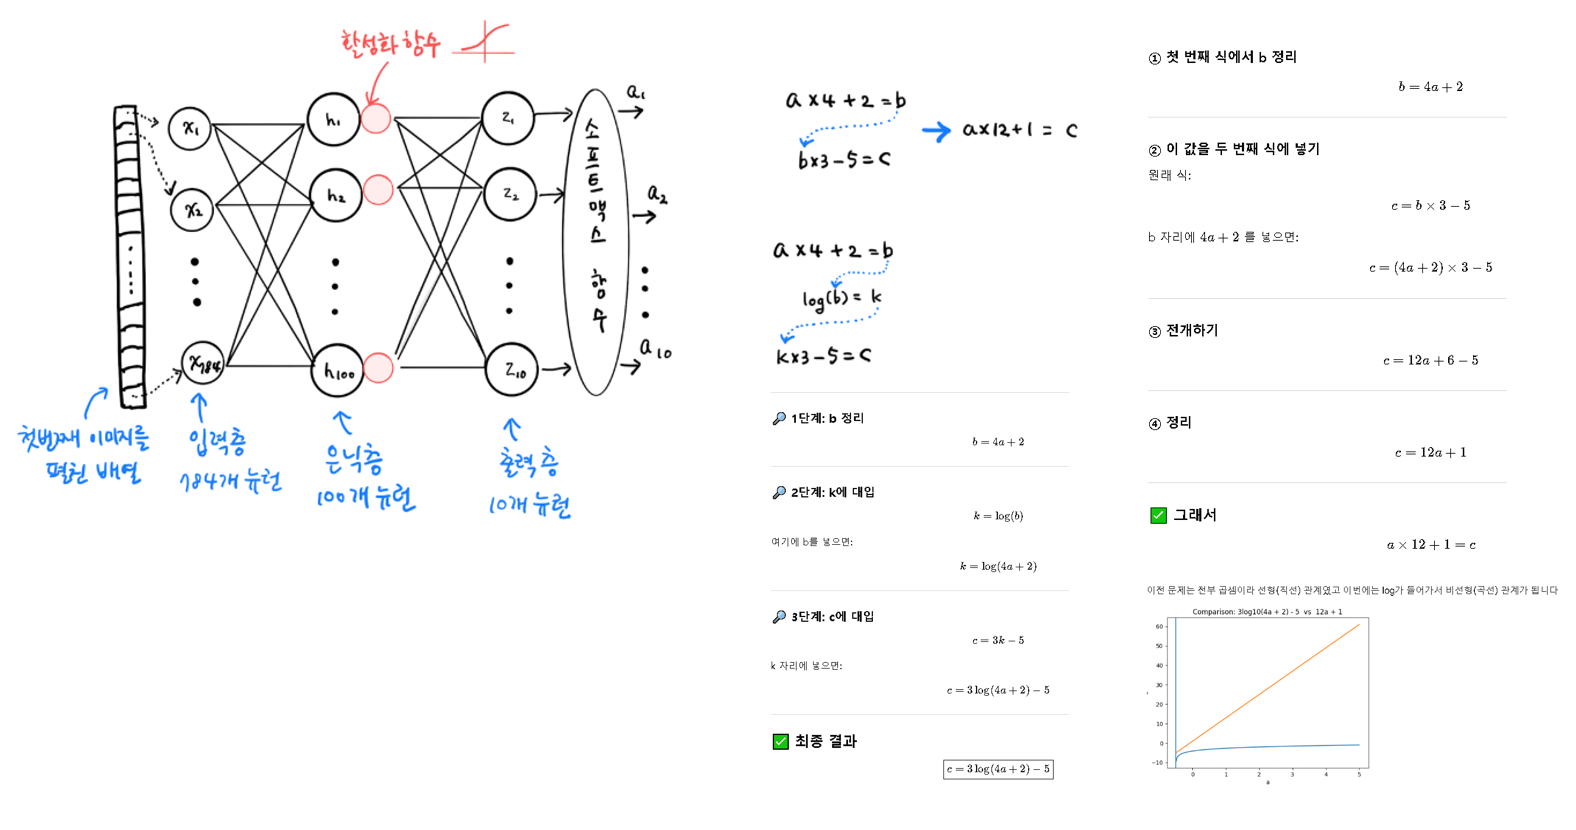

In [22]:
# 시그모이드 활성화 함수를 사용한 은닉층과 소프트맥스 함수를 사용한 출력층을 케라스 Dense 클래스로 만들어보자.

dense1 = keras.layers.Dense(100, activation = 'sigmoid', input_shape = (784,))

# input_shape = (784,) 입력의 크기 필수
# dense1의 목표 : 784개의 입력을 시그모이드 함수를 이용해 100개로 만들자
# https://gooopy.tistory.com/52

# dense1이 은닉층이고 100개의 뉴런을 가진 밀집층, 활성화 함수를 시그모이드로 설정
# 몇개의 뉴런이 필요할 지는 경험적으로 기입
# 제약사항으로는 적어도 출력층의 뉴런보다는 많게 만들어야 한다.
# 클래스 10개에 대한 확률을 예측해야 하는데, 은닉층의 뉴런이 10개 이하면 안된다.

dense2 = keras.layers.Dense(10, activation = 'softmax')

# dense2는 출력층으로 설정(10개의 클래스를 분류하므로 10개의 뉴런을 둔다.)
# https://wikidocs.net/120089
# 활성화 함수로 소프트 맥스 함수로 지정

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# 심층 신경망 만들기(순차적으로 적용하기 위한 모델)
model = keras.Sequential([dense1, dense2])

# 위에서 만든 dense1, dense2를 Sequential 클래스에 추가하여 심층(deep) 신경망을 만든다.

# dense1, dense2를 리스트로 만들어 전달.
# 주의 : 뒤에가 출력층이므로 dense2를 설정
# 인공신경망의 강력한 성능은 층을 추가하여 입력데이터에 대해 연속적인 학습을 진행하는 능력
#   → 2개 이상 층을 추가할 수 있다.

In [24]:
# 층에 대한 유용한 정보가 나온다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 맨 첫줄에 모델의 이름, 그 다음 이 모델이 들어 있는 층이 순서대로 나온다.
# 맨 처음 추가한 은닉층에서 출력층의 순서대로 나온다.

# 층이름(클래스), 출력크기, 모델 파라미터 갯수
# 층이름을 지정하지 않으면 케라스가 자동으로 Dense라고 이름을 붙인다.
# 출력크기(None(샘플의 개수 : 아직 정의되지 않았다.), 100)
#   → 미니배치 경사 하강법 : 케라스 모델의 fit() 메서드에 훈련데이터를 주입하면
#      이 데이터를 한번에 모두 사용하지 않고 잘게 나누어 여러번 걸쳐 경사 하강법 단계를 수행
#      케라스의 기본 미니배치 크기는 32개이다.(8의 배수 사용)
#      Dense : 여러 개를 꺼내서 전달하는 역할

# 이 값은 fit() 메서드에서 batch_size 매개변수로 변경 가능하다.
# 따라서 샘플 개수를 고정하지 않고 어떤 배치 크기에도 유연하게 대응할 수 있도록 None으로 설정이 최선.

# 신경망 층에서 입력되거나 출력되는 배열의 첫번째 차원을 배치자원이라고 부른다.

# 출력크기(None, 100 → 은닉층의 뉴런개수를 100개이므로 100개의 출력이 나온다.)
#   → 샘플마다 784개의 픽셀 값이 은닉층을 통과하면서 100개의 특성으로 압축
# 마지막으로 파라미터 개수가 출력된다. 784 * 100 + 100 = 78500

# ** 공식 암기 ** : 입력개수 * 출력개수(절편) + 출력개수(절편) = 파라미터 수

In [ ]:
# 두번째 층의 출력 크기 (None, 10) → 뉴런 개수가 10개
# 파라미터는 100 * 10 + 10 = 1010개

# 맨 아래 있는 Non-trainable params : 0(0.00 B)는 훈련되지 않는 파라미터.
# 간혹 경사 하강법으로 훈련되지 않는 파라미터를 가진 층의 파라미터.

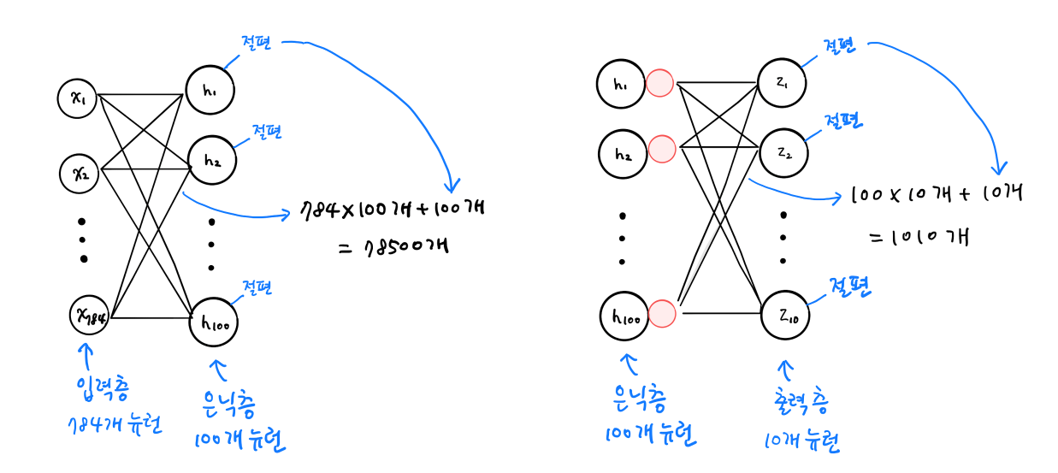

In [26]:
# 모델을 만들면서 층을 추가하는 방법
# Sequential 클래스에 층을 추가하는 다른 방법
# 앞에 2개의 Dense는 따로 저장하여 쓸일이 없기 때문에
# 아래코드처럼 Sequential 클래스의 생성자 안에서 바로 Dense 클래스의 객체를 만드는 경우가 많다.

model = keras.Sequential([
    keras.layers.Dense(100, activation = 'sigmoid', input_shape = (784, ), name = 'hidden'),
    keras.layers.Dense(10, activation = 'softmax', name = 'output')], name = '패션 MNIST 모델')

# name = 'hidden' : 레이어 이름 정의(영어만) / name = '패션 MNIST 모델' : 모델의 이름

model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 층(layer) 추가시 가장 편한 방법은 .add()를 사용

# 새로운 모델 생성
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation = 'sigmoid', input_shape = (784,)))
model.add(keras.layers.Dense(10, activation = 'softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 모델 훈련 시작
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# 처음 훈련에는 75.25% 였으나 5번의 반복을 통해 87.59% 향상
model.fit(train_scaled, train_target, epochs = 5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7508 - loss: 0.7770
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8466 - loss: 0.4251
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8599 - loss: 0.3851
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8674 - loss: 0.3606
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8740 - loss: 0.3424


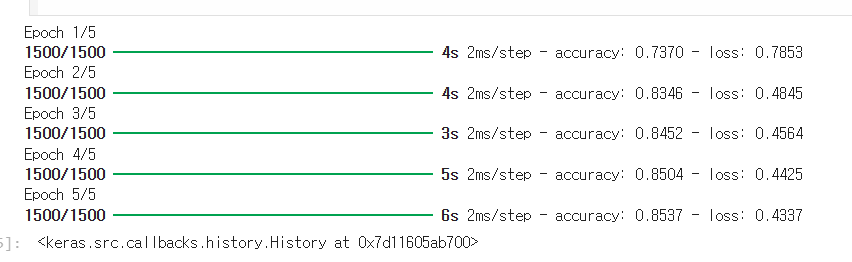

In [30]:
# 1개의 층으로만 돌렸을 때 정확도 : 85.37%
# 2개의 층으로 돌렸을 때 : 87.40%로 향상

# 훈련결과를 보면 훈련세트에 대한 성능이 추가된 층이 성능을 향상시켰다는 것을 알 수 있다.
model.evaluate(val_scaled, val_target)
# 검증 점수 87.28%

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8728 - loss: 0.3549


[0.3571808636188507, 0.8684166669845581]

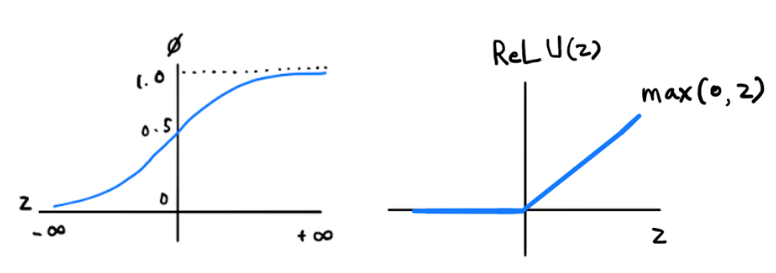

In [31]:
# 초창기 인공신경망의 은닉층에서 많이 사용된 활성화 함수는 시그모이드 함수였지만
# 단점이 오른쪽, 왼쪽 끝으로 갈수록 그래프가 누워 올바른 출력을 만드는데 신속하게 대응하지 못한다.
# 특히 층이 많은 심층 신경망일수록 그 효과가 누적되어 학습을 더 어렵게 만든다.

# 렐루(ReLU) 함수 : 개선을 위해서 다른 종류의 활성화 함수가 제안된 것.
# 렐루 함수는 입력이 양수일 경우 마치 활성화 함수가 없는 것처럼
# 그냥 입력을 통과시키고 음수일 경우 0으로 만든다.
# 0보다 작으면 0으로 만들고, 0보다 크면 그 값을 그대로 내보낸다.

# 렐루함수는 max(0, z)와 같이 쓴다.
#   → z가 0보다 크면 z를 출력하고 0 보다 작으면 0을 출력

# 시그모이드 함수는 값이 커지면 기울기가 0에 가까워져 학습신호가 끝까지 전달되지 않는
# 기울기 소실 현상이 발생하여 렐루 함수를 사용한다.

# 렐루함수는 특히 이미지 처리에 좋은 성능을 낸다고 한다.
# 은닉 층에 활성화 함수에 시그모이드 함수 대신 렐루 함수를 적용하기 전에
# 케라스에서 제공하는 편리한 층 하나를 더 알아볼 필요가 있다. → Flatten(이미지 픽셀용)
# Flatten(플래튼) : 단조롭게하다(28 * 28 = 784가 아니라 그냥 28,28로 입력)
# 클래스는 배치자원을 제외하고 나머지 입력 차원을 모두 일렬로 펼치는 역할만 한다.(가중치, 절편 X)

# 절편 : 직선이 x축과 만나는 점의 x좌표(x절편) 및 y축과 만나는 점의 y좌표(y절편)를 통틀어 이르는 말
# 하지만 플리튼 클래스를 층처럼 입력층과 은닉층 사이에 추가하기 때문에 이를 층이라고 부른다.
# 입력층 바로 뒤에 플래튼 층 추가

In [34]:
model = keras.Sequential()

# 입력층 바로 뒤에 플래튼 층 추가
model.add(keras.layers.Flatten(input_shape = (28, 28)))
# 플래튼 클래스에 포함된 파라미터는 0개로 케라스의 플래튼 층을 신경망 모델에 추가하면
# 입력값의 차원을 짐작할 수 있는 것이 장점이 된다.

# (None, 784) → 784개의 입력이 첫번째 은닉층에 전달되는 것을 알 수 있다.

# 렐루층 : true / false를 1단계에서 검사
model.add(keras.layers.Dense(100, activation = 'relu'))

# 소프트맥스층 : 다중분류
model.add(keras.layers.Dense(10, activation = 'softmax'))

# 여기까지가 딥러닝 모델 생성 끝!
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# 훈련데이터를 준비해서 모델 훈련 시작
# reshape() 메서드 제외 → 2차원 해상도 값을 그대로 사용
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42)

In [36]:
# 플래튼 사용하기 위해 픽셀값 조정 X
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [37]:
# 플래튼 사용하기 위해 픽셀값 조정 X
print(train_scaled.shape, test_target.shape)

(48000, 28, 28) (10000,)


In [38]:
# 플래튼을 사용하려고 픽셀값 조정 X
print(val_scaled.shape, val_target.shape)

(12000, 28, 28) (12000,)


In [42]:
# 순차적인 모델을 생성한 후 컴파일을 통해 빠른 처리를 위한다.
model.compile(loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# 훈련시작(에포크 5번 반복)
model.fit(train_scaled, train_target, epochs = 5)

# 전 시그모이드(87.59%)와 비교해보면 조금 향상되었다. (27초 소요)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9097 - loss: 0.2632
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9149 - loss: 0.2515
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9153 - loss: 0.2466
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9179 - loss: 0.2409
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9191 - loss: 0.2366


In [41]:
# 검증점수 전(87.33%와 비교해보면 좋지 않다.)
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8685 - loss: 0.4129


[0.41084229946136475, 0.8677499890327454]

In [43]:
# 옵티마이져 : 최적화

# 하이퍼파라미터는 모델이 학습하지 않아 사람이 지정해주어야 하는 파라미터
# 신경망에는 특히 하이퍼파라미터가 많다.

# 전에는 하나의 은닉층으로 추가하였으나 여러개의 은닉층을 추가할 수도 있다.
# 추가할 은닉층의 개수는 모델이 학습하는 것이 아니라 우리가 지정해주어야 할 하이퍼파라미터.
# 은닉층의 뉴런개수도 우리가 지정하는 것이 하이퍼파라미터이다.(활성화 함수, 층의 종류 포함)

# 케라스는 기본적으로 미니배치 경사 하강법을 사용하며 미니배치 개수는 32개라고 했다.
# 이를 조정하는 batch_size가 하이퍼 파라미터
# fit() 메서드의 epochs(에포크 : 중요한 사건시점) 매개변수도 하이퍼파라미터이다.
#   → 반복한 횟수에 따라 다른 모델이 만들어진다.

# 마지막으로 compile() 메서드에서는 케라스의 기본 경사 하강법 알고리즘인
# RMSprop(Root Mean Sqaure Propagation의 약자로, 알엠에스프롭(R.M.S.Prop)이라고 읽는다.)
# 옵티마이저(optimizer : 최적화) : 케라스는 다양한 종류의 경사 하강법을 제공, 학습률 또한 조정할 하이퍼파라미터

# 처음부터 모델을 구성하고 각종 하이퍼파라미터의 최적값을 찾는 것은 어려운 작업.

# 옵티마이저 테스트1 → 확률적 경사 하강법 AGD
# 1개의 샘플을 뽑아 훈련하지 않고 앞서 언급한것처럼 기본적인 미니배치를 사용

# SGD : "하나씩 해결하면서 문제해결도 같이." (단순하지만 좀 갈팡질팡.)
# RMSprop : "많이 틀린 유형에 더 집중해서 해결." (똑똑하게 속도를 조절.)
# Adam : "지금까지 해온 학습 유지, 문제해결 같이" (가장 공부를 잘하는 만능 열공법!)

# SGD 최적화 객체를 생성하여 변수로 넣는 방법
sgd = keras.optimizers.SGD()
model.compile(optimizer = sgd, loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# optimizer = 'sgd' 자동으로 클래스를 객체로 만들고 시작
# sgd = keras.optimizers.SGD() 생략 가능
model.compile(optimizer = 'sgd', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
# 위에꺼 정리

# 옵티마이저 : 최적화를 위해 하이퍼 파라미터를 자동으로 튜닝한다.

# 하이퍼 파라미터 : 모델이 자동으로 학습하지 않기 때문에 사용자가 직접 지정해야 하는 파라미터
# 1. 모델의 형태(구조)를 결정하는 하이퍼 파라미터
# 1) 은닉층의 개수 : 층을 얼마나 깊게 쌓을 것인가?
# 2) 뉴런의 개수 : 각 층에 지능(노드)을 얼마나 많이 배치할 것인가?
# 3) 활성화 함수 : 다음 층으로 신호를 보낼 때 어떤 기준(e.g. ReLU, Sigmoid)을 사용할 것인가?
# 4) 층의 종류 : 밀집층(Dense)을 사용할 것인가, 아니면 다른 층을 사용할 것인가?

# 2. 학습 방식(훈련)을 결정하는 하이퍼 파라미터
# 1) 배치 크기( batch_size) : 한 번에 몇 개의 데이터를 묶어서 공부할 것인가? (기본값 : 32)
# 2) 에포크(epochs) : 전체 데이터를 총 몇 번 반복해서 학습할 것인가?
# 3) 학습률(learning rate) : 가중치를 업데이트 할 때 얼마나 세밀하게 조정할 것인가?

# R(oot)M(ean)S(quare)prop(agation) : 케라스에서 'compile' 호출 시 별도 설정이 없으면 사용하는 옵티마이저 → 최근의 기울기 변화량을 고려하여 학습 속도를 적절하게 조절한다.
# S(tochastic) G(radient) D(escent) : 가장 고전적이고 기본이 되는 옵티마이저 → 원칙적으로 1개의 샘플만을 보며 내려가지만, 케라스는 효율을 위해 미니 배치 하강법을 사용한다.

In [ ]:
# 하이퍼파라미터 : 기계가 정하는 것이 아닌 사람이 손으로 직접 써넣어야 한다.(반복횟수, 층개수 등)
# 옵티마이저 : 정답과 내 답 사이의 차이를 줄이기 위해 어떤 길로 갈지 안내하는 가이드
# 학습률 : 정답을 향해 갈 때 한걸음의 폭을 얼마나 크게 할 것인가.

In [45]:
# learning_rate = 0.1 원하는 학습률 기록(기본값 0.01)
sgd = keras.optimizers.SGD(learning_rate=0.1)

# 아래그림처럼 다양한 최적화 기법이 존재
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

# 모멘텀(기본0 : 글레디언트 가속도 0.9이상 사용)
# 네스테로프 모멘텀(네스테로프 모멘텀 최적화 = 가속경사)
# 네스테로프 모멘텀은 모멘텀 최적화를 2번 반복하여 구현
#   → 기본 확률적 경사 하강법보다 더 나은 성능을 제공

# 모델이 최적점에 가까이 갈수록 학습률을 낮출 수도 있다.
#   → 안정적으로 최적점에 수렴(적응적 학습률 : adaptive learning rate)
# 학습률 매개변수를 튜닝하는 수고를 줄여준다.

# 적응적 학습률
# : adaptive learning rate를 사용하는 대표적인 최적화 기법은 Adatrad, RMSprop가 있다.
# ompile() 메서드의 optimizer = adagrad, optimizer = rmsprop(기본값)

adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

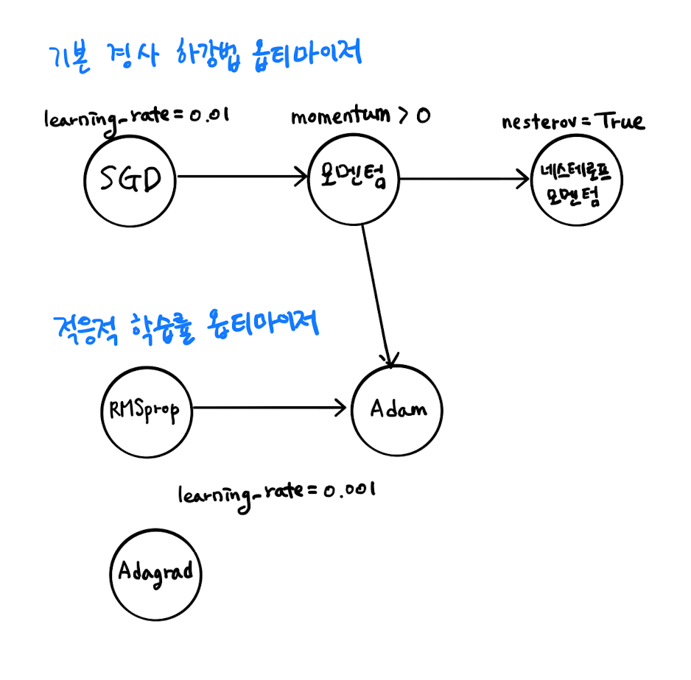

In [46]:
# RMSprop로 최적화 하는 방법
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer = rmsprop, loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [47]:
# 딥러닝의 레이어 생성
model = keras.Sequential()

# 입력층(1차원 변환없이 사용)
model.add(keras.layers.Flatten(input_shape = (28, 28)))

# 은닉층(렐루)
model.add(keras.layers.Dense(100, activation = 'relu'))

# 출력층(소프트맥스)
model.add(keras.layers.Dense(10, activation = 'softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(optimizer='adagrad', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 적응적 학습률 최적화(에이다그레드)
model.fit(train_scaled, train_target, epochs = 5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5269 - loss: 1.5234
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7469 - loss: 0.8030
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7818 - loss: 0.6957
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7973 - loss: 0.6437
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8045 - loss: 0.6110


In [50]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 적응적 학습률 최적화
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8009 - loss: 0.5685
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8524 - loss: 0.4035
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8700 - loss: 0.3602
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8806 - loss: 0.3344
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8874 - loss: 0.3176


In [51]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# adam : 모멘텀 최적화와 RMSprop의 장점을 접목한 기법(대부분 adam을 사용)
model.fit(train_scaled, train_target, epochs = 5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8889 - loss: 0.3040
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8982 - loss: 0.2807
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9032 - loss: 0.2652
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9060 - loss: 0.2546
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9116 - loss: 0.2401


In [53]:
# 검증 성능 확인 88.15점
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8848 - loss: 0.3433


[0.3510265648365021, 0.8815000057220459]

In [54]:
# 마지막 평가점수 분석(스케일 조정 필수)
test_scaled = test_input / 255.0

model.evaluate(test_scaled, test_target)

# 예를 들어 테스트 데이터가 10,000개라면 → 약 8,560개 맞춤
# 손실 0.3643은 평균적으로 정답 클래스에 약 69~70% 확신을 가진 상태,
# 정확도 87%와 일관된 정상적인 Cross Entropy 값이다.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8735 - loss: 0.3665


[0.3680822253227234, 0.8730999827384949]

In [55]:
model.predict(test_input[0 : 1])
# 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [56]:
model.predict(test_input[10 : 21])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 9.9999994e-01, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 9.9999994e-01,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 9.9999994e-01,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        9.9999994e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 9.9999994e-01, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.00